In [2]:
# temporary imports (should be included in next image iteration)
!pip install matplotlib
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 36.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 41.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 14.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 45.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]


In [84]:
import os
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

In [8]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [9]:
FREESOUND_API_KEY = ""
with open("../fsk.env", "r") as f:
    FREESOUND_API_KEY = f.read().split("=")[1]
    FREESOUND_API_KEY = FREESOUND_API_KEY.replace("\n", "").replace('"','')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [10]:
# HELPERS

def query_freesound(query, filter, num_results=10):
    """Queries freesound with the given query and filter values.
    If no filter is given, a default filter is added to only get sounds shorter than 10 seconds.
    """
    if filter is None:
        filter = 'duration:[0 TO 10]'

    pager = client.search(
        query=query,
        filter=filter,
        fields=','.join(FREESOUND_STORE_METADATA_FIELDS),
        group_by_pack=1,
        page_size=num_results
    )

    return [sound for sound in pager]


def retrieve_sound_preview(sound, directory):
    """Download the high-quality OGG sound preview of a given Freesound sound object to the given directory.
    """
    os.makedirs(directory, exist_ok=True)

    filename = os.path.basename(sound.previews.preview_hq_ogg)
    path = os.path.join(directory, filename)

    if os.path.exists(path):
        print(f"File {path} already downloaded.")
        return path

    return freesound.FSRequest.retrieve(
        sound.previews.preview_hq_ogg,
        client,
        path,
    )


def sounds_to_dataframe(sounds, audio_dir):
    rows = []

    for sound in sounds:
        filename = os.path.basename(sound.previews.preview_hq_ogg)

        rows.append({
            "sound_id": sound.id,
            "name": sound.name,
            "username": sound.username,
            "license": sound.license,
            "tags": ",".join(sound.tags),
            "preview_url": sound.previews.preview_hq_ogg,
            "local_path": os.path.join(audio_dir, filename)
        })

    return pd.DataFrame(rows)


def delete_dataset(meta_csv_path):
    if os.path.exists(meta_csv_path):
        df = pd.read_csv(meta_csv_path)
    
        for path in df["local_path"]:
            if os.path.exists(path):
                os.remove(path)
                print(f"Deleted audio file: {path}")
            else:
                print(f"Missing file (skipped): {path}")
                
        os.remove(meta_csv_path)
        print(f"Deleted metadata file: {meta_csv_path}")
    else:
        print(f"Not found metadata file: {meta_csv_path} (skipping)")

    json_path = meta_csv_path[:meta_csv_path.rfind(".")] + ".json"
    if os.path.exists(json_path):
        os.remove(json_path)
        print(f"Deleted query file: {json_path}")

In [29]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [16]:
# Queries for THIS RUN
freesound_queries = [
    {
        "query": "dog bark",
        "filter": None,
        "num_results": 20,
    },
    {
        "query": "repeated hits",
        "filter": None,
        "num_results": 20,
    },
]

In [41]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = []
for q in freesound_queries:
    sounds.extend(
        query_freesound(
            query=q["query"],
            filter=q["filter"],
            num_results=q["num_results"],
        )
    )

print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(sound, AUDIO_DIR)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, AUDIO_DIR)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "queries": freesound_queries,
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 40 sound metadata objects
[1/40] Downloading sound ID 236215
[2/40] Downloading sound ID 612856
[3/40] Downloading sound ID 625498
[4/40] Downloading sound ID 418105
[5/40] Downloading sound ID 749351
[6/40] Downloading sound ID 160093
[7/40] Downloading sound ID 242413
[8/40] Downloading sound ID 485962
[9/40] Downloading sound ID 277058
[10/40] Downloading sound ID 495658
[11/40] Downloading sound ID 609488
[12/40] Downloading sound ID 649020
[13/40] Downloading sound ID 455492
[14/40] Downloading sound ID 536631
[15/40] Downloading sound ID 607895
[16/40] Downloading sound ID 591786
[17/40] Downloading sound ID 723371
[18/40] Downloading sound ID 166268
[19/40] Downloading sound ID 743462
[20/40] Downloading sound ID 7913
[21/40] Downloading sound ID 655915
[22/40] Downloading sound ID 531378
[23/40] Downloading sound ID 664130
[24/40] Downloading sound ID 492586
[25/40] Downloading sound ID 514387
[26/40] Downloading sound ID 117198
[27/40] Downloading sound ID 273968
[28

In [18]:
!ls ../data/meta

dataset_2026-01-11_18-43-37.csv   dataset_2026-01-12_16-04-58.csv
dataset_2026-01-11_18-43-37.json  dataset_2026-01-12_16-04-58.json


In [20]:
delete_dataset(META_DIR + "dataset_2026-01-12_16-04-58.csv")

Deleted audio file: ../data/audio/236215_180659-hq.ogg
Missing file (skipped): ../data/audio/612856_13194336-hq.ogg
Deleted audio file: ../data/audio/625498_13366994-hq.ogg
Deleted audio file: ../data/audio/418105_6078577-hq.ogg
Missing file (skipped): ../data/audio/749351_16213215-hq.ogg
Missing file (skipped): ../data/audio/160093_2888453-hq.ogg
Missing file (skipped): ../data/audio/242413_4165591-hq.ogg
Deleted audio file: ../data/audio/485962_6150892-hq.ogg
Missing file (skipped): ../data/audio/277058_4486188-hq.ogg
Missing file (skipped): ../data/audio/495658_7932944-hq.ogg
Deleted audio file: ../data/audio/609488_321967-hq.ogg
Missing file (skipped): ../data/audio/649020_3571340-hq.ogg
Missing file (skipped): ../data/audio/455492_1138747-hq.ogg
Missing file (skipped): ../data/audio/536631_9771749-hq.ogg
Missing file (skipped): ../data/audio/607895_7405868-hq.ogg
Missing file (skipped): ../data/audio/591786_12659364-hq.ogg
Missing file (skipped): ../data/audio/723371_14337212-hq.o

### Show downloaded audio

In [97]:
def detect_onsets(audio_path, sample_rate=44100):
    audio = es.MonoLoader(
        filename=audio_path,
        sampleRate=sample_rate
    )()
    
    # The OnsetDetection algorithm provides various ODFs.
    od_complex = es.OnsetDetection(method='complex')
    
    # We need the auxilary algorithms to compute magnitude and phase.
    w = es.Windowing(type='hann')
    fft = es.FFT() # Outputs a complex FFT vector.
    c2p = es.CartesianToPolar() # Converts it into a pair of magnitude and phase vectors.
    
    # Compute both ODF frame by frame. Store results to a Pool.
    pool = essentia.Pool()
    for frame in es.FrameGenerator(audio, frameSize=1024, hopSize=512):
        magnitude, phase = c2p(fft(w(frame)))
        pool.add('odf.complex', od_complex(magnitude, phase))
    
    # 2. Detect onset locations.
    onsets = es.Onsets()
    onset_times = onsets(essentia.array([pool['odf.complex']]), [1])

    return audio, onset_times


In [77]:
def plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=44100,
    start_time=None,
    end_time=None
):
    # Convert times to sample indices
    start_sample = int(start_time * sample_rate) if start_time is not None else 0
    end_sample = int(end_time * sample_rate) if end_time is not None else len(audio)

    audio_seg = audio[start_sample:end_sample]
    time_axis = np.arange(len(audio_seg)) / sample_rate

    plt.figure(figsize=(14, 6))
    plt.plot(time_axis, audio_seg, linewidth=0.8)

    for onset in onset_times:
        if start_time is None or onset >= start_time:
            if end_time is None or onset <= end_time:
                plt.axvline(onset - (start_time or 0), color='red', linestyle='--', alpha=0.7)

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Waveform with detected onsets")
    plt.tight_layout()
    plt.show()


In [40]:
!ls ../data/audio

In [45]:
# select a file manually
filename = "117198_117285-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/117198_117285-hq.ogg'

In [81]:
# select a file randomly
filename = random.choice(os.listdir(AUDIO_DIR))
filename = AUDIO_DIR + filename
filename

'../data/audio/514387_1738686-hq.ogg'

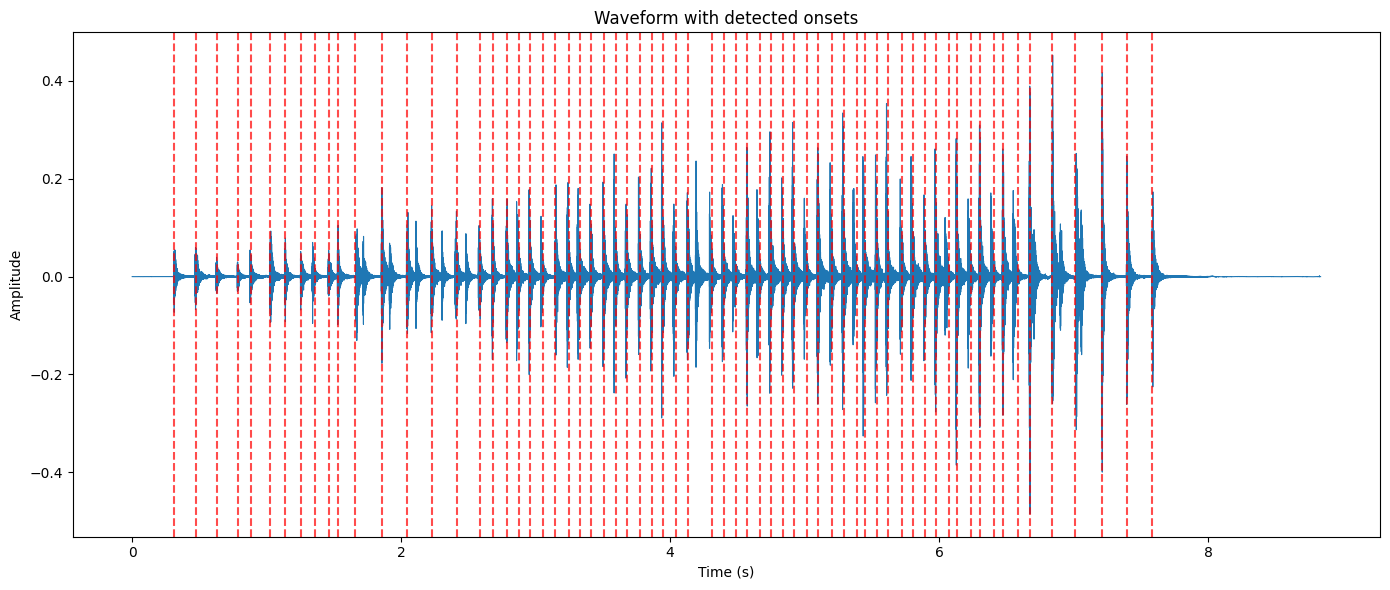

In [102]:
start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filename)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)